# 12_first_graph_based_forecasting_baseline.ipynb

## Σκοπός του notebook

Αυτό το notebook αποτελεί το **πρώτο actual graph-based forecasting baseline**
του repository μετά το packaging layer του `NB11`.

Στόχος του είναι να:

- καταναλώσει **μόνο** τα canonical packaged graph artifacts του `NB11`,
- ορίσει ένα **minimal, benchmark-safe, graph-only** forecasting baseline,
- προετοιμάσει καθαρά το training-ready graph dataset interface,
- και να παραμείνει πλήρως ευθυγραμμισμένο με το forecasting-first scope του repo.

## Τι ΔΕΝ κάνει αυτό το notebook στο παρόν scaffold pass

Σε αυτό το πρώτο scaffold pass, το notebook:

- **δεν** ξαναχτίζει raw preprocessing,
- **δεν** ξανακάνει split logic,
- **δεν** ξανακάνει graph packaging,
- **δεν** αλλάζει το `data/processed/baseline_metrics.csv`,
- **δεν** ανοίγει sequence-model scope,
- **δεν** κάνει PHM / fault / prognostics claims.

## Μεθοδολογική θέση

Το `NB10` λειτούργησε ως graph-contract verification stage.
Το `NB11` λειτούργησε ως graph-model input packaging stage.
Το παρόν `NB12` είναι το πρώτο notebook που προχωρά σε
**πραγματικό graph-based forecasting model definition**.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import importlib
import json
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display

# ============================================================
# Fail-fast import policy για PyTorch Geometric
# ============================================================
try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GCNConv
except Exception as exc:
    raise ImportError(
        "Το NB12 απαιτεί εγκατεστημένο το torch_geometric. "
        "Επιβεβαίωσε ότι το environment του repo έχει το σωστό dependency stack."
    ) from exc


# ============================================================
# Reproducibility helpers
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Προσπαθούμε να κάνουμε το run όσο γίνεται πιο deterministic.
# Σημείωση:
# Η απόλυτη determinism μπορεί να έχει performance trade-offs.
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("SEED:", SEED)
print("DEVICE:", DEVICE)
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

SEED: 42
DEVICE: cpu
torch version: 2.10.0+cpu
CUDA available: False


## Logged pitfalls που ενσωματώνουμε στο NB12

Το παρόν notebook γράφεται ώστε να **μην επαναλάβει** γνωστά methodological mistakes
που ήδη καταγράφηκαν στα προηγούμενα στάδια:

1. Δεν γίνεται loose reparsing raw timestamps downstream.
2. Δεν ξαναεισάγεται raw-validation logic μετά το `NB02`.
3. Δεν ξαναχτίζεται graph contract που ήδη σταθεροποιήθηκε στο `NB10`.
4. Δεν ξαναγίνεται packaging logic που ήδη σταθεροποιήθηκε στο `NB11`.
5. Δεν γίνεται mutation του canonical benchmark artifact `baseline_metrics.csv`.
6. Δεν αγνοείται το `observed_mask`.
7. Δεν χρησιμοποιούνται hidden / implicit assumptions για node order ή feature space.
8. Όλα τα core checks είναι **fail-fast** και όχι silent-fallback.

In [2]:
# ============================================================
# Project-root / path helpers
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το repository root ανεβαίνοντας από το current working directory.
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους `data/` και `notebooks/`."
    )


def resolve_under_root(path_like: str | Path, root: Path) -> Path:
    """
    Αν το path είναι σχετικό, το επιλύουμε κάτω από το project root.
    """
    path_obj = Path(path_like)
    return path_obj if path_obj.is_absolute() else (root / path_obj)


ROOT = find_project_root(Path.cwd())

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

try:
    cfg = importlib.import_module("src.config")
except Exception:
    cfg = None


def cfg_get(name: str, default: Any) -> Any:
    """
    Διαβάζει attribute από το src.config μόνο αν υπάρχει.
    """
    if cfg is None:
        return default
    return getattr(cfg, name, default)


# ============================================================
# Canonical constants
# ============================================================
PARK_ID_COLUMN = cfg_get("PARK_ID_COLUMN", "park_id")
TIMESTAMP_COLUMN = cfg_get("TIMESTAMP_COLUMN", "timestamp")
TARGET_COLUMN = cfg_get("TARGET_COLUMN", "Power_Output_Normalized")
BASELINE_COLUMN = cfg_get("BASELINE_COLUMN", "Baseline_Prediction")

NB11_EXPORT_DIR = resolve_under_root(
    cfg_get("NB11_EXPORT_DIR", "data/processed/graph_packaging"),
    ROOT,
)

TRAIN_GRAPH_PACKAGE_PATH = resolve_under_root(
    cfg_get("NB11_TRAIN_GRAPH_DATASET", NB11_EXPORT_DIR / "train_graph_dataset.pt"),
    ROOT,
)
VAL_GRAPH_PACKAGE_PATH = resolve_under_root(
    cfg_get("NB11_VAL_GRAPH_DATASET", NB11_EXPORT_DIR / "val_graph_dataset.pt"),
    ROOT,
)
TEST_GRAPH_PACKAGE_PATH = resolve_under_root(
    cfg_get("NB11_TEST_GRAPH_DATASET", NB11_EXPORT_DIR / "test_graph_dataset.pt"),
    ROOT,
)

NB11_FEATURE_ROLE_MANIFEST_PATH = resolve_under_root(
    cfg_get("NB11_FEATURE_ROLE_MANIFEST", NB11_EXPORT_DIR / "nb11_feature_role_manifest.csv"),
    ROOT,
)
NB11_NODE_FEATURE_MANIFEST_PATH = resolve_under_root(
    cfg_get("NB11_NODE_FEATURE_MANIFEST", NB11_EXPORT_DIR / "nb11_node_feature_manifest.csv"),
    ROOT,
)

BASELINE_METRICS_PATH = resolve_under_root(
    cfg_get("BASELINE_METRICS_PATH", "data/processed/baseline_metrics.csv"),
    ROOT,
)

# ΝΕΟ export namespace για το NB12.
NB12_EXPORT_DIR = resolve_under_root(
    "data/processed/graph_baselines/nb12_first_graph_baseline",
    ROOT,
)
NB12_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("NB11_EXPORT_DIR:", NB11_EXPORT_DIR)
print("NB12_EXPORT_DIR:", NB12_EXPORT_DIR)

ROOT: C:\Users\diony\Desktop\WindPower_DigitalTwin
NB11_EXPORT_DIR: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_packaging
NB12_EXPORT_DIR: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline


## Canonical input contract του NB12

Το `NB12` οφείλει να καταναλώσει **μόνο** τα serialized packaged artifacts του `NB11`.

Στο current implementation υποθέτουμε ότι τα core input artifacts είναι:

- `train_graph_dataset.pt`
- `val_graph_dataset.pt`
- `test_graph_dataset.pt`
- `nb11_feature_role_manifest.csv`
- `nb11_node_feature_manifest.csv`

Το `baseline_metrics.csv` παραμένει μόνο **read-only reference artifact**
για μεταγενέστερη benchmark comparison και δεν χρησιμοποιείται στο current scaffold pass.

In [3]:
# ============================================================
# Load helpers
# ============================================================

def ensure_file_exists(path: Path) -> None:
    """
    Fail-fast έλεγχος ύπαρξης αρχείου.
    """
    if not path.exists():
        raise FileNotFoundError(f"Λείπει required artifact: {path}")


def load_package(path: Path, expected_split_name: str) -> dict[str, Any]:
    """
    Φορτώνει serialized NB11 package και ελέγχει το split_name.
    """
    ensure_file_exists(path)

    package = torch.load(path, map_location="cpu")

    if not isinstance(package, dict):
        raise TypeError(f"Το package στο {path} δεν είναι dict.")

    actual_split_name = package.get("split_name", None)
    if actual_split_name != expected_split_name:
        raise ValueError(
            f"Ασυμφωνία split_name στο {path}. "
            f"Expected={expected_split_name}, found={actual_split_name}"
        )

    return package


# ============================================================
# Load NB11 outputs
# ============================================================
train_package = load_package(TRAIN_GRAPH_PACKAGE_PATH, "train")
val_package = load_package(VAL_GRAPH_PACKAGE_PATH, "val")
test_package = load_package(TEST_GRAPH_PACKAGE_PATH, "test")

ensure_file_exists(NB11_FEATURE_ROLE_MANIFEST_PATH)
ensure_file_exists(NB11_NODE_FEATURE_MANIFEST_PATH)

feature_role_manifest_df = pd.read_csv(NB11_FEATURE_ROLE_MANIFEST_PATH)
node_feature_manifest_df = pd.read_csv(NB11_NODE_FEATURE_MANIFEST_PATH)

print("Loaded packages successfully.")
print("Feature role manifest rows:", len(feature_role_manifest_df))
print("Node feature manifest rows:", len(node_feature_manifest_df))

Loaded packages successfully.
Feature role manifest rows: 48
Node feature manifest rows: 48


## Fail-fast integrity checks πάνω στο NB11 handoff

Πριν φτιάξουμε dataset / model interface, ελέγχουμε ότι το packaging handoff
είναι shape-safe, contract-safe και split-safe.

Κρίσιμο:
το `NB12` **δεν** διορθώνει σιωπηλά broken packages.
Αν κάτι είναι λάθος, αποτυγχάνει ρητά.

In [4]:
# ============================================================
# Required package schema
# ============================================================

REQUIRED_PACKAGE_KEYS = {
    "split_name",
    "node_ids",
    "timestamps",
    "edge_index",
    "edge_attr_km",
    "static_x",
    "dynamic_x",
    "target_y",
    "baseline_reference",
    "observed_mask",
    "static_feature_names",
    "dynamic_feature_names",
    "target_name",
    "baseline_name",
    "n_nodes",
    "n_timestamps",
    "n_static_features",
    "n_dynamic_features",
}

def assert_required_keys(package: dict[str, Any], split_name: str) -> None:
    missing = sorted(REQUIRED_PACKAGE_KEYS - set(package.keys()))
    if missing:
        raise KeyError(f"Το split `{split_name}` λείπει required keys: {missing}")


def assert_package_tensor_shapes(package: dict[str, Any], split_name: str) -> None:
    static_x = package["static_x"]
    dynamic_x = package["dynamic_x"]
    target_y = package["target_y"]
    baseline_reference = package["baseline_reference"]
    observed_mask = package["observed_mask"]
    edge_index = package["edge_index"]
    edge_attr_km = package["edge_attr_km"]

    if static_x.ndim != 2:
        raise ValueError(f"`{split_name}` static_x πρέπει να είναι 2D.")
    if dynamic_x.ndim != 3:
        raise ValueError(f"`{split_name}` dynamic_x πρέπει να είναι 3D [T, N, D].")
    if target_y.ndim != 2:
        raise ValueError(f"`{split_name}` target_y πρέπει να είναι 2D [T, N].")
    if baseline_reference.ndim != 2:
        raise ValueError(f"`{split_name}` baseline_reference πρέπει να είναι 2D [T, N].")
    if observed_mask.ndim != 2:
        raise ValueError(f"`{split_name}` observed_mask πρέπει να είναι 2D [T, N].")
    if edge_index.ndim != 2 or edge_index.shape[0] != 2:
        raise ValueError(f"`{split_name}` edge_index πρέπει να είναι shape [2, E].")
    if edge_attr_km.ndim != 2:
        raise ValueError(f"`{split_name}` edge_attr_km πρέπει να είναι 2D [E, A].")

    # Cross-shape checks
    if tuple(observed_mask.shape) != tuple(target_y.shape):
        raise ValueError(
            f"`{split_name}` observed_mask και target_y δεν έχουν ίδιο shape."
        )

    if tuple(baseline_reference.shape) != tuple(target_y.shape):
        raise ValueError(
            f"`{split_name}` baseline_reference και target_y δεν έχουν ίδιο shape."
        )

    if dynamic_x.shape[0] != target_y.shape[0]:
        raise ValueError(f"`{split_name}` ασυμφωνία T ανάμεσα σε dynamic_x και target_y.")
    if dynamic_x.shape[1] != target_y.shape[1]:
        raise ValueError(f"`{split_name}` ασυμφωνία N ανάμεσα σε dynamic_x και target_y.")

    if static_x.shape[0] != target_y.shape[1]:
        raise ValueError(f"`{split_name}` static_x δεν ταιριάζει στο node dimension.")

    if edge_attr_km.shape[0] != edge_index.shape[1]:
        raise ValueError(f"`{split_name}` edge_attr_km δεν ταιριάζει στο πλήθος edges.")

    if int(observed_mask.sum().item()) == 0:
        raise ValueError(f"`{split_name}` δεν έχει καμία observed node entry.")

    observed_per_timestamp = observed_mask.sum(dim=1)
    if torch.any(observed_per_timestamp == 0):
        raise ValueError(
            f"`{split_name}` περιέχει timestamp χωρίς καμία observed node entry."
        )


def assert_observed_entries_are_not_nan(package: dict[str, Any], split_name: str) -> None:
    observed_mask = package["observed_mask"].cpu()
    target_y = package["target_y"].cpu()
    baseline_reference = package["baseline_reference"].cpu()
    dynamic_x = package["dynamic_x"].cpu()

    # observed target entries
    if torch.isnan(target_y)[observed_mask].any():
        raise ValueError(f"`{split_name}` έχει NaN target_y πάνω σε observed entries.")

    # observed baseline entries
    if torch.isnan(baseline_reference)[observed_mask].any():
        raise ValueError(f"`{split_name}` έχει NaN baseline_reference πάνω σε observed entries.")

    # observed dynamic entries
    if dynamic_x.numel() > 0:
        observed_mask_3d = observed_mask.unsqueeze(-1).expand_as(dynamic_x)
        if torch.isnan(dynamic_x)[observed_mask_3d].any():
            raise ValueError(f"`{split_name}` έχει NaN dynamic_x πάνω σε observed entries.")


for split_name, package in {
    "train": train_package,
    "val": val_package,
    "test": test_package,
}.items():
    assert_required_keys(package, split_name)
    assert_package_tensor_shapes(package, split_name)
    assert_observed_entries_are_not_nan(package, split_name)

# ============================================================
# Cross-split contract checks
# ============================================================

if train_package["node_ids"] != val_package["node_ids"] or train_package["node_ids"] != test_package["node_ids"]:
    raise ValueError("Ασυμφωνία node_ids ordering μεταξύ train / val / test packages.")

if train_package["static_feature_names"] != val_package["static_feature_names"] or train_package["static_feature_names"] != test_package["static_feature_names"]:
    raise ValueError("Ασυμφωνία static_feature_names μεταξύ splits.")

if train_package["dynamic_feature_names"] != val_package["dynamic_feature_names"] or train_package["dynamic_feature_names"] != test_package["dynamic_feature_names"]:
    raise ValueError("Ασυμφωνία dynamic_feature_names μεταξύ splits.")

if not torch.equal(train_package["edge_index"], val_package["edge_index"]) or not torch.equal(train_package["edge_index"], test_package["edge_index"]):
    raise ValueError("Ασυμφωνία edge_index topology μεταξύ splits.")

if not torch.equal(train_package["edge_attr_km"], val_package["edge_attr_km"]) or not torch.equal(train_package["edge_attr_km"], test_package["edge_attr_km"]):
    raise ValueError("Ασυμφωνία edge_attr_km μεταξύ splits.")

print("NB11 handoff integrity checks passed.")

NB11 handoff integrity checks passed.


,split_name,n_timestamps,n_nodes,n_static_features,n_dynamic_features,partial_timestamp_count,full_coverage_timestamp_count,min_observed_nodes_per_timestamp,max_observed_nodes_per_timestamp,mean_observed_nodes_per_timestamp
0,train,7819,256,5,36,6494,1325,244,256,253.579230
1,val,720,256,5,36,593,127,249,256,254.163889
2,test,4295,256,5,36,4096,199,245,256,252.930384


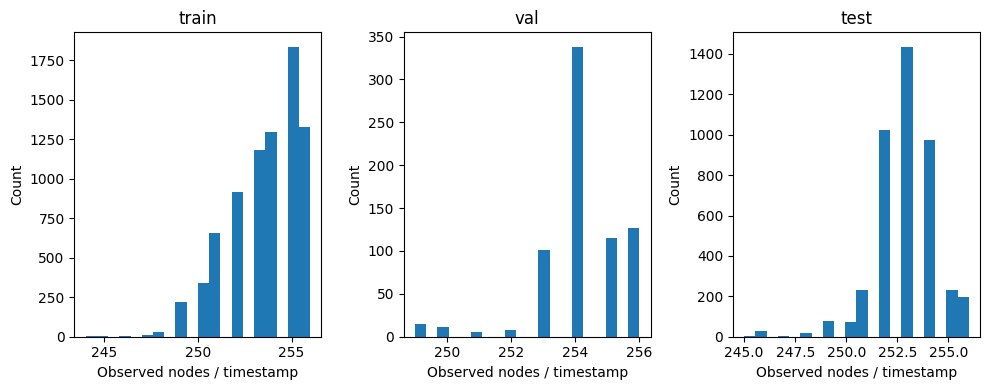

In [5]:
# ============================================================
# Compact package summary
# ============================================================

def summarize_package(package: dict[str, Any]) -> dict[str, Any]:
    observed_per_timestamp = package["observed_mask"].sum(dim=1).cpu().numpy()

    return {
        "split_name": package["split_name"],
        "n_timestamps": int(package["n_timestamps"]),
        "n_nodes": int(package["n_nodes"]),
        "n_static_features": int(package["n_static_features"]),
        "n_dynamic_features": int(package["n_dynamic_features"]),
        "partial_timestamp_count": int(package["partial_timestamp_count"]),
        "full_coverage_timestamp_count": int(package["full_coverage_timestamp_count"]),
        "min_observed_nodes_per_timestamp": int(observed_per_timestamp.min()),
        "max_observed_nodes_per_timestamp": int(observed_per_timestamp.max()),
        "mean_observed_nodes_per_timestamp": float(observed_per_timestamp.mean()),
    }

package_summary_df = pd.DataFrame(
    [
        summarize_package(train_package),
        summarize_package(val_package),
        summarize_package(test_package),
    ]
)

display(package_summary_df)

# ============================================================
# Coverage histograms
# ============================================================
fig = plt.figure(figsize=(10, 4))

for i, package in enumerate([train_package, val_package, test_package], start=1):
    observed_per_timestamp = package["observed_mask"].sum(dim=1).cpu().numpy()

    ax = fig.add_subplot(1, 3, i)
    ax.hist(observed_per_timestamp, bins=20)
    ax.set_title(package["split_name"])
    ax.set_xlabel("Observed nodes / timestamp")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Snapshot-level graph dataset design

Για το πρώτο graph baseline χρησιμοποιούμε την εξής formulation:

- κάθε **timestamp** αντιστοιχεί σε ένα graph snapshot,
- οι **κόμβοι** είναι τα parks,
- οι **ακμές** είναι το canonical `edge_index`,
- το node feature matrix είναι:
  - `static_x`
  - `dynamic_x[t]`
  - `observed_indicator`

Σημαντική απόφαση:
δεν χρησιμοποιούμε ακόμη το `baseline_reference` ως input feature,
ώστε το πρώτο graph baseline να παραμείνει καθαρό και benchmark-safe.

Επίσης:
όπου υπάρχουν unobserved node entries, κάνουμε safe numeric fill μόνο στο input tensor,
αλλά η **loss / metrics λογική** θα στηριχθεί αργότερα αποκλειστικά στο `observed_mask`.

In [6]:
# ============================================================
# Dataset wrapper: one graph per timestamp
# ============================================================

class TemporalGraphSnapshotDataset(torch.utils.data.Dataset):
    """
    Dataset που μετατρέπει ένα packaged split σε λίστα από graph snapshots.

    Κάθε item αντιστοιχεί σε ένα timestamp.
    Το x φτιάχνεται ως concat(static_x, dynamic_x[t], observed_indicator).
    """

    def __init__(
        self,
        package: dict[str, Any],
        include_observed_indicator: bool = True,
        fill_value: float = 0.0,
    ) -> None:
        self.package = package
        self.include_observed_indicator = include_observed_indicator
        self.fill_value = fill_value

        self.timestamps = list(package["timestamps"])
        self.node_ids = list(package["node_ids"])

        self.input_feature_names = (
            list(package["static_feature_names"])
            + list(package["dynamic_feature_names"])
        )

        if self.include_observed_indicator:
            self.input_feature_names = self.input_feature_names + ["observed_indicator"]

        self.n_input_features = len(self.input_feature_names)

    def __len__(self) -> int:
        return int(self.package["n_timestamps"])

    def _build_x(self, t_index: int) -> torch.Tensor:
        """
        Φτιάχνει node feature matrix για ένα timestamp.
        """
        static_x = self.package["static_x"]                         # [N, S]
        dynamic_x_t = self.package["dynamic_x"][t_index]           # [N, D]
        observed_mask_t = self.package["observed_mask"][t_index]   # [N]

        # Safe fill για unobserved entries ή τυχόν NaN entries εκτός observed scope.
        dynamic_x_t = torch.nan_to_num(
            dynamic_x_t,
            nan=self.fill_value,
            posinf=self.fill_value,
            neginf=self.fill_value,
        )

        parts = [static_x, dynamic_x_t]

        if self.include_observed_indicator:
            observed_indicator = observed_mask_t.to(torch.float32).unsqueeze(-1)  # [N, 1]
            parts.append(observed_indicator)

        x = torch.cat(parts, dim=1)

        if x.ndim != 2:
            raise ValueError(f"Expected 2D node feature matrix, found shape={tuple(x.shape)}")

        return x

    def __getitem__(self, index: int) -> Data:
        if not (0 <= index < len(self)):
            raise IndexError(f"Index out of range: {index}")

        x = self._build_x(index)

        data = Data(
            x=x,
            edge_index=self.package["edge_index"],
            y=self.package["target_y"][index],
        )

        # Κρατάμε edge_attr για μελλοντική επέκταση, έστω κι αν η πρώτη GCN δεν το χρησιμοποιεί.
        data.edge_attr = self.package["edge_attr_km"]

        # observed mask για μελλοντική masked loss / masked metrics.
        data.observed_mask = self.package["observed_mask"][index]

        # baseline reference διατηρείται μόνο για downstream inspection / future comparison.
        data.baseline_reference = self.package["baseline_reference"][index]

        # Tensor-only metadata ώστε να είναι DataLoader-safe.
        data.time_index = torch.tensor([index], dtype=torch.long)
        data.num_nodes = int(self.package["n_nodes"])

        return data


train_dataset = TemporalGraphSnapshotDataset(train_package)
val_dataset = TemporalGraphSnapshotDataset(val_package)
test_dataset = TemporalGraphSnapshotDataset(test_package)

print("Datasets created successfully.")
print("Train snapshots:", len(train_dataset))
print("Val snapshots  :", len(val_dataset))
print("Test snapshots :", len(test_dataset))
print("Input feature dim:", train_dataset.n_input_features)

Datasets created successfully.
Train snapshots: 7819
Val snapshots  : 720
Test snapshots : 4295
Input feature dim: 42


In [7]:
# ============================================================
# Sample inspection
# ============================================================

sample = train_dataset[0]

print(sample)
print("-" * 80)
print("sample.x shape           :", tuple(sample.x.shape))
print("sample.y shape           :", tuple(sample.y.shape))
print("sample.edge_index shape  :", tuple(sample.edge_index.shape))
print("sample.edge_attr shape   :", tuple(sample.edge_attr.shape))
print("sample.observed_mask shape:", tuple(sample.observed_mask.shape))
print("sample.num_nodes         :", sample.num_nodes)
print("first train timestamp    :", train_dataset.timestamps[0])

assert sample.x.shape[0] == train_package["n_nodes"]
assert sample.y.shape[0] == train_package["n_nodes"]
assert sample.observed_mask.shape[0] == train_package["n_nodes"]
assert sample.x.shape[1] == train_dataset.n_input_features

preview_feature_df = pd.DataFrame(
    {
        "input_feature_name": train_dataset.input_feature_names
    }
)

display(preview_feature_df.head(20))

Data(x=[256, 42], edge_index=[2, 1068], y=[256], edge_attr=[1068, 1], observed_mask=[256], baseline_reference=[256], time_index=[1], num_nodes=256)
--------------------------------------------------------------------------------
sample.x shape           : (256, 42)
sample.y shape           : (256,)
sample.edge_index shape  : (2, 1068)
sample.edge_attr shape   : (1068, 1)
sample.observed_mask shape: (256,)
sample.num_nodes         : 256
first train timestamp    : 2018-12-08 06:00:00


,input_feature_name
0,lat
1,long
2,hub_height_m
3,rotor_diameter_m
4,nominal_power_kW
5,nwp_fcst_horiz_hours
6,T_HAG_2_M
7,RELHUM_HAG_2_M
8,PS_SFC_0_M
9,U_GVL_58_HL


## DataLoader policy

Για το πρώτο baseline κρατάμε μικρά και καθαρά mini-batches από graph snapshots.

- `shuffle=True` μόνο στο train
- `shuffle=False` σε validation / test
- δεν χρησιμοποιούμε ακόμη neighbor sampling
- δεν χρησιμοποιούμε ακόμη temporal windows
- δεν κάνουμε ακόμη graph sequence batching

Αυτό κρατά το πρώτο `NB12` όσο γίνεται πιο καθαρό:
**spatial graph baseline first, temporal complexity later**

In [8]:
# ============================================================
# DataLoaders
# ============================================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("BATCH_SIZE:", BATCH_SIZE)
print("Train loader batches:", len(train_loader))
print("Val loader batches  :", len(val_loader))
print("Test loader batches :", len(test_loader))

BATCH_SIZE: 16
Train loader batches: 489
Val loader batches  : 45
Test loader batches : 269


## Επιλογή minimal graph model

Για το πρώτο actual graph baseline επιλέγουμε **2-layer GCN node regressor**.

Γιατί όχι GraphSAGE στο πρώτο pass;

- το `GCN` είναι πιο canonical και πιο minimal,
- έχει πιο καθαρό official pattern,
- είναι αρκετό για να μετρήσουμε την πρώτη spatial graph contribution,
- αποφεύγουμε επιπλέον aggregation hyperparameters στο πρώτο benchmark-safe pass.

Το output είναι **μία scalar πρόβλεψη ανά node**.

In [9]:
# ============================================================
# Minimal GCN node regressor
# ============================================================

class GCNNodeRegressor(nn.Module):
    """
    Minimal node-level regression GCN για το πρώτο graph-based forecasting pass.
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int = 64,
        dropout: float = 0.20,
    ) -> None:
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.head = nn.Linear(hidden_channels, 1)

        self.dropout = float(dropout)

    def forward(self, data: Data) -> torch.Tensor:
        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.head(x).squeeze(-1)

        return out


model = GCNNodeRegressor(
    in_channels=train_dataset.n_input_features,
    hidden_channels=64,
    dropout=0.20,
).to(DEVICE)

print(model)

GCNNodeRegressor(
  (conv1): GCNConv(42, 64)
  (conv2): GCNConv(64, 64)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


## Mask-aware loss utilities

Το `NB11` μάς έδωσε `observed_mask`.
Το `NB12` οφείλει να το χρησιμοποιήσει.

Στο scaffold pass ορίζουμε από τώρα τις core masked utilities:

- masked MSE loss
- masked MAE
- masked RMSE
- masked R²

Έτσι το training/evaluation phase που θα ακολουθήσει δεν θα κάνει
λάθος πάνω σε unobserved nodes.

In [10]:
# ============================================================
# Mask-aware regression utilities
# ============================================================

def validate_masked_shapes(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> None:
    """
    Σιγουρεύει ότι pred / target / mask είναι συμβατά.
    """
    if pred.shape != target.shape:
        raise ValueError(f"pred και target δεν έχουν ίδιο shape: {pred.shape} vs {target.shape}")
    if pred.shape != mask.shape:
        raise ValueError(f"pred και mask δεν έχουν ίδιο shape: {pred.shape} vs {mask.shape}")
    if mask.dtype != torch.bool:
        raise TypeError(f"Το mask πρέπει να είναι bool tensor, found={mask.dtype}")


def select_valid_entries(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Επιλέγει πρώτα μόνο τα valid observed entries.
    Αυτό είναι κρίσιμο για να μη μπαίνουν NaN/unobserved values
    στο arithmetic path πριν από το masking.
    """
    validate_masked_shapes(pred, target, mask)

    valid_count = int(mask.sum().item())
    if valid_count == 0:
        raise ValueError("Το mask δεν περιέχει κανένα valid entry.")

    pred_valid = pred[mask]
    target_valid = target[mask]

    if pred_valid.numel() == 0 or target_valid.numel() == 0:
        raise ValueError("Μετά το masking δεν έμειναν valid entries.")

    return pred_valid, target_valid


def masked_mse_loss(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    """
    Safe masked MSE: πρώτα mask, μετά loss.
    """
    pred_valid, target_valid = select_valid_entries(pred, target, mask)
    return F.mse_loss(pred_valid, target_valid, reduction="mean")


def masked_mae(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    """
    Safe masked MAE: πρώτα mask, μετά absolute error.
    """
    pred_valid, target_valid = select_valid_entries(pred, target, mask)
    return torch.abs(pred_valid - target_valid).mean()


def masked_rmse(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    mse = masked_mse_loss(pred, target, mask)
    return torch.sqrt(mse)


def masked_r2(
    pred: torch.Tensor,
    target: torch.Tensor,
    mask: torch.Tensor,
) -> torch.Tensor:
    """
    Safe masked R² πάνω μόνο στα valid observed entries.
    """
    pred_valid, target_valid = select_valid_entries(pred, target, mask)

    ss_res = torch.sum((target_valid - pred_valid) ** 2)
    ss_tot = torch.sum((target_valid - torch.mean(target_valid)) ** 2)

    if torch.isclose(ss_tot, torch.tensor(0.0, device=target.device)):
        return torch.tensor(float("nan"), device=target.device)

    return 1.0 - (ss_res / ss_tot)


print("Mask-aware utilities ready (safe version).")

Mask-aware utilities ready (safe version).


In [11]:
# ============================================================
# Pre-training forward sanity pass
# ============================================================

first_batch = next(iter(train_loader))
first_batch = first_batch.to(DEVICE)

model.eval()
with torch.no_grad():
    first_pred = model(first_batch)

print("first_pred shape        :", tuple(first_pred.shape))
print("first_batch.y shape     :", tuple(first_batch.y.shape))
print("first_batch.mask shape  :", tuple(first_batch.observed_mask.shape))

assert first_pred.shape == first_batch.y.shape
assert first_pred.shape == first_batch.observed_mask.shape

first_loss = masked_mse_loss(first_pred, first_batch.y, first_batch.observed_mask)
first_mae = masked_mae(first_pred, first_batch.y, first_batch.observed_mask)
first_rmse = masked_rmse(first_pred, first_batch.y, first_batch.observed_mask)

print("Initial masked MSE :", float(first_loss.cpu()))
print("Initial masked MAE :", float(first_mae.cpu()))
print("Initial masked RMSE:", float(first_rmse.cpu()))

first_pred shape        : (4096,)
first_batch.y shape     : (4096,)
first_batch.mask shape  : (4096,)
Initial masked MSE : 6548172.0
Initial masked MAE : 2543.864990234375
Initial masked RMSE: 2558.939697265625


In [12]:
# ============================================================
# Numeric audit before training
# ============================================================

def audit_tensor(name: str, tensor: torch.Tensor) -> None:
    t = tensor.detach().cpu()

    finite_mask = torch.isfinite(t)
    finite_count = int(finite_mask.sum().item())
    total_count = t.numel()

    print(f"\n{name}")
    print("-" * len(name))
    print("shape         :", tuple(t.shape))
    print("dtype         :", t.dtype)
    print("finite values :", f"{finite_count} / {total_count}")

    if finite_count > 0:
        finite_values = t[finite_mask]
        print("min           :", float(finite_values.min().item()))
        print("max           :", float(finite_values.max().item()))
        print("mean          :", float(finite_values.mean().item()))
        print("std           :", float(finite_values.std().item()))
    else:
        print("No finite values found.")


train_obs = train_package["observed_mask"]

audit_tensor("train static_x", train_package["static_x"])
audit_tensor("train dynamic_x (all entries)", train_package["dynamic_x"])
audit_tensor("train dynamic_x (observed only)", train_package["dynamic_x"][train_obs])
audit_tensor("train target_y (all entries)", train_package["target_y"])
audit_tensor("train target_y (observed only)", train_package["target_y"][train_obs])
audit_tensor("train baseline_reference (observed only)", train_package["baseline_reference"][train_obs])


train static_x
--------------
shape         : (256, 5)
dtype         : torch.float32
finite values : 1280 / 1280
min           : 6.0
max           : 7580.0
mean          : 593.8809204101562
std           : 1342.667724609375



train dynamic_x (all entries)
-----------------------------
shape         : (7819, 256, 36)
dtype         : torch.float32
finite values : 71378496 / 72059904
min           : -24.360000610351562
max           : 104662.0546875
mean          : 2747.23046875
std           : 16157.896484375

train dynamic_x (observed only)
-------------------------------
shape         : (1982736, 36)
dtype         : torch.float32
finite values : 71378496 / 71378496
min           : -24.360000610351562
max           : 104662.0546875
mean          : 2747.23046875
std           : 16157.896484375

train target_y (all entries)
----------------------------
shape         : (7819, 256)
dtype         : torch.float32
finite values : 1982736 / 2001664
min           : 0.0
max           : 0.9883512258529663
mean          : 0.1729341447353363
std           : 0.26983046531677246

train target_y (observed only)
------------------------------
shape         : (1982736,)
dtype         : torch.float32
finite values : 1982736 /

## Scaffold status

Το `NB12` είναι πλέον:

- package-aware,
- graph-ready,
- DataLoader-ready,
- model-ready,
- και mask-aware.

Στο επόμενο pass θα προστεθούν:

- training loop
- validation-driven model selection
- final test evaluation
- benchmark-safe comparison
- NB12-specific exports

χωρίς mutation του canonical `baseline_metrics.csv`.

## Phase 2 — Training, validation, and benchmark-safe evaluation

Σε αυτό το phase το `NB12` περνά από το model-ready scaffold
σε ένα πλήρες πρώτο graph-based forecasting baseline.

Στόχοι του Phase 2:

- να οριστεί reproducible training configuration,
- να υλοποιηθεί καθαρός training loop με masked loss,
- να χρησιμοποιηθεί το validation split μόνο για model selection,
- να γίνει μία τελική test evaluation στο best checkpoint,
- να δημιουργηθεί benchmark-safe comparison απέναντι στο existing tabular backbone,
- και να εξαχθούν μόνο NB12-specific outputs χωρίς mutation του canonical benchmark artifact.

In [13]:
# ============================================================
# Training configuration
# ============================================================

TRAINING_CONFIG = {
    "batch_size": BATCH_SIZE,
    "hidden_channels": 64,
    "dropout": 0.20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "max_epochs": 30,
    "patience": 6,
    "min_delta": 1e-5,
    "gradient_clip_norm": 1.0,
}

print("Training configuration:")
for key, value in TRAINING_CONFIG.items():
    print(f"  - {key}: {value}")

Training configuration:
  - batch_size: 16
  - hidden_channels: 64
  - dropout: 0.2
  - learning_rate: 0.001
  - weight_decay: 1e-05
  - max_epochs: 30
  - patience: 6
  - min_delta: 1e-05
  - gradient_clip_norm: 1.0


## Training design choices

Για το πρώτο graph baseline κρατάμε σκόπιμα ένα πολύ καθαρό training setup:

- optimizer: `Adam`
- loss: **masked MSE**
- model selection: **validation RMSE**
- early stopping: patience πάνω στο validation loss
- final reporting: μόνο στο **test split** με το best validation checkpoint

Σημαντικό:
το `baseline_metrics.csv` θα διαβαστεί αργότερα μόνο ως read-only benchmark reference.
Δεν θα γίνει overwrite ή append στο canonical artifact.

In [14]:
# ============================================================
# Optimizer / checkpoint state
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=TRAINING_CONFIG["learning_rate"],
    weight_decay=TRAINING_CONFIG["weight_decay"],
)

best_state_dict = None
best_epoch = None
best_val_loss = float("inf")
epochs_without_improvement = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_mae": [],
    "train_rmse": [],
    "val_loss": [],
    "val_mae": [],
    "val_rmse": [],
    "val_r2": [],
}

print("Optimizer ready.")

Optimizer ready.


## Batch aggregation policy

Επειδή το `PyG DataLoader` ενώνει πολλά graph snapshots σε ένα batch,
οι node-level προβλέψεις, targets και masks έρχονται flattened στο merged batch space.

Αυτό είναι απολύτως αποδεκτό για το current setup, αρκεί:

- το model να επιστρέφει node-level scalar prediction,
- το `y` να είναι node-level scalar target,
- και το `observed_mask` να είναι στο ίδιο flattened space.

Άρα τα masked metrics μπορούν να υπολογιστούν απευθείας στο batch output.

In [15]:
# ============================================================
# Epoch helpers (with non-finite guards)
# ============================================================

def tensor_to_float(value: torch.Tensor) -> float:
    return float(value.detach().cpu().item())


def assert_finite_tensor(name: str, tensor: torch.Tensor) -> None:
    if not torch.isfinite(tensor).all():
        raise FloatingPointError(f"Detected non-finite values in `{name}`.")


def run_training_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    gradient_clip_norm: float | None = None,
) -> dict[str, float]:
    model.train()

    batch_losses = []
    batch_maes = []
    batch_rmses = []
    valid_counts = []

    for batch_idx, batch in enumerate(loader):
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(batch)
        target = batch.y
        mask = batch.observed_mask

        pred_valid, target_valid = select_valid_entries(pred, target, mask)

        assert_finite_tensor(f"pred_valid (train batch {batch_idx})", pred_valid)
        assert_finite_tensor(f"target_valid (train batch {batch_idx})", target_valid)

        loss = masked_mse_loss(pred, target, mask)
        mae = masked_mae(pred, target, mask)
        rmse = masked_rmse(pred, target, mask)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite train loss at batch {batch_idx}.")
        if not torch.isfinite(mae):
            raise FloatingPointError(f"Non-finite train MAE at batch {batch_idx}.")
        if not torch.isfinite(rmse):
            raise FloatingPointError(f"Non-finite train RMSE at batch {batch_idx}.")

        loss.backward()

        if gradient_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_norm)

        optimizer.step()

        batch_losses.append(tensor_to_float(loss))
        batch_maes.append(tensor_to_float(mae))
        batch_rmses.append(tensor_to_float(rmse))
        valid_counts.append(int(mask.sum().item()))

    if len(batch_losses) == 0:
        raise ValueError("Το training loader δεν παρήγαγε κανένα batch.")

    return {
        "loss": float(np.mean(batch_losses)),
        "mae": float(np.mean(batch_maes)),
        "rmse": float(np.mean(batch_rmses)),
        "mean_valid_nodes": float(np.mean(valid_counts)),
    }


@torch.no_grad()
def run_eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> dict[str, float]:
    model.eval()

    batch_losses = []
    batch_maes = []
    batch_rmses = []
    batch_r2s = []
    valid_counts = []

    for batch_idx, batch in enumerate(loader):
        batch = batch.to(device)

        pred = model(batch)
        target = batch.y
        mask = batch.observed_mask

        pred_valid, target_valid = select_valid_entries(pred, target, mask)

        assert_finite_tensor(f"pred_valid (eval batch {batch_idx})", pred_valid)
        assert_finite_tensor(f"target_valid (eval batch {batch_idx})", target_valid)

        loss = masked_mse_loss(pred, target, mask)
        mae = masked_mae(pred, target, mask)
        rmse = masked_rmse(pred, target, mask)
        r2 = masked_r2(pred, target, mask)

        if not torch.isfinite(loss):
            raise FloatingPointError(f"Non-finite eval loss at batch {batch_idx}.")
        if not torch.isfinite(mae):
            raise FloatingPointError(f"Non-finite eval MAE at batch {batch_idx}.")
        if not torch.isfinite(rmse):
            raise FloatingPointError(f"Non-finite eval RMSE at batch {batch_idx}.")

        batch_losses.append(tensor_to_float(loss))
        batch_maes.append(tensor_to_float(mae))
        batch_rmses.append(tensor_to_float(rmse))
        batch_r2s.append(float(r2.detach().cpu().item()))
        valid_counts.append(int(mask.sum().item()))

    if len(batch_losses) == 0:
        raise ValueError("Το evaluation loader δεν παρήγαγε κανένα batch.")

    return {
        "loss": float(np.mean(batch_losses)),
        "mae": float(np.mean(batch_maes)),
        "rmse": float(np.mean(batch_rmses)),
        "r2": float(np.nanmean(batch_r2s)),
        "mean_valid_nodes": float(np.mean(valid_counts)),
    }


print("Training / evaluation helpers ready (guarded version).")

Training / evaluation helpers ready (guarded version).


In [16]:
# ============================================================
# Single-epoch smoke test
# ============================================================

smoke_train_metrics = run_training_epoch(
    model=model,
    loader=train_loader,
    optimizer=optimizer,
    device=DEVICE,
    gradient_clip_norm=TRAINING_CONFIG["gradient_clip_norm"],
)

smoke_val_metrics = run_eval_epoch(
    model=model,
    loader=val_loader,
    device=DEVICE,
)

print("Smoke train metrics:", smoke_train_metrics)
print("Smoke val metrics  :", smoke_val_metrics)

Smoke train metrics: {'loss': 194311.68269713718, 'mae': 98.00544139790084, 'rmse': 123.46202261563093, 'mean_valid_nodes': 4054.674846625767}
Smoke val metrics  : {'loss': 0.06111415231393443, 'mae': 0.18546277847554948, 'rmse': 0.2400127311547597, 'r2': -0.34747580422295465, 'mean_valid_nodes': 4066.6222222222223}


## Full training loop with early stopping

Από εδώ και πέρα το notebook θα κάνει:

1. training στο train split,
2. evaluation στο validation split,
3. model selection με βάση το best validation loss,
4. early stopping όταν δεν υπάρχει meaningful improvement.

Το test split παραμένει untouched μέχρι το τέλος.

In [17]:
# ============================================================
# Reinitialize model before the real training run
# ============================================================

model = GCNNodeRegressor(
    in_channels=train_dataset.n_input_features,
    hidden_channels=TRAINING_CONFIG["hidden_channels"],
    dropout=TRAINING_CONFIG["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=TRAINING_CONFIG["learning_rate"],
    weight_decay=TRAINING_CONFIG["weight_decay"],
)

best_state_dict = None
best_epoch = None
best_val_loss = float("inf")
epochs_without_improvement = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_mae": [],
    "train_rmse": [],
    "val_loss": [],
    "val_mae": [],
    "val_rmse": [],
    "val_r2": [],
}

print("Model and optimizer reinitialized for the full run.")

Model and optimizer reinitialized for the full run.


In [18]:
# ============================================================
# Full training loop
# ============================================================

for epoch in range(1, TRAINING_CONFIG["max_epochs"] + 1):
    train_metrics = run_training_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        gradient_clip_norm=TRAINING_CONFIG["gradient_clip_norm"],
    )

    val_metrics = run_eval_epoch(
        model=model,
        loader=val_loader,
        device=DEVICE,
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_metrics["loss"])
    history["train_mae"].append(train_metrics["mae"])
    history["train_rmse"].append(train_metrics["rmse"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_mae"].append(val_metrics["mae"])
    history["val_rmse"].append(val_metrics["rmse"])
    history["val_r2"].append(val_metrics["r2"])

    improved = (best_val_loss - val_metrics["loss"]) > TRAINING_CONFIG["min_delta"]

    if improved:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.6f} | "
        f"train_rmse={train_metrics['rmse']:.6f} | "
        f"val_loss={val_metrics['loss']:.6f} | "
        f"val_rmse={val_metrics['rmse']:.6f} | "
        f"val_r2={val_metrics['r2']:.6f}"
    )

    if epochs_without_improvement >= TRAINING_CONFIG["patience"]:
        print(
            f"Early stopping triggered at epoch {epoch}. "
            f"Best epoch was {best_epoch} with val_loss={best_val_loss:.6f}"
        )
        break

if best_state_dict is None:
    raise RuntimeError("Δεν αποθηκεύτηκε best_state_dict κατά το training.")

print("Training completed.")
print("Best epoch   :", best_epoch)
print("Best val loss:", best_val_loss)

Epoch 01 | train_loss=79542.588307 | train_rmse=72.506108 | val_loss=0.060642 | val_rmse=0.238194 | val_r2=-0.305958
Epoch 02 | train_loss=0.078018 | train_rmse=0.273836 | val_loss=0.060948 | val_rmse=0.239411 | val_r2=-0.333939
Epoch 03 | train_loss=0.074011 | train_rmse=0.269298 | val_loss=0.060551 | val_rmse=0.237788 | val_r2=-0.296396
Epoch 04 | train_loss=0.073398 | train_rmse=0.268828 | val_loss=0.061092 | val_rmse=0.239936 | val_r2=-0.345752
Epoch 05 | train_loss=0.073376 | train_rmse=0.268715 | val_loss=0.060482 | val_rmse=0.237461 | val_r2=-0.288589
Epoch 06 | train_loss=0.073704 | train_rmse=0.269165 | val_loss=0.061007 | val_rmse=0.239630 | val_r2=-0.338874
Epoch 07 | train_loss=0.072815 | train_rmse=0.268224 | val_loss=0.061050 | val_rmse=0.239784 | val_r2=-0.342348
Epoch 08 | train_loss=0.072823 | train_rmse=0.268097 | val_loss=0.061305 | val_rmse=0.240668 | val_r2=-0.362058
Epoch 09 | train_loss=0.073162 | train_rmse=0.268371 | val_loss=0.060803 | val_rmse=0.238856 | val_

## Phase 3 — Final test evaluation, benchmark-safe comparison, and exports

Σε αυτό το τελικό phase του `NB12`:

- επαναφορτώνουμε το best validation checkpoint,
- κάνουμε μία τελική evaluation στο test split,
- δημιουργούμε benchmark-safe comparison απέναντι στο implemented tabular backbone,
- και εξάγουμε μόνο NB12-specific outputs.

Σημαντικό:
το canonical artifact `data/processed/baseline_metrics.csv` παραμένει **read-only**.
Το `NB12` δεν το μεταβάλλει.

In [19]:
# ============================================================
# Restore best checkpoint
# ============================================================

if best_state_dict is None:
    raise RuntimeError("Λείπει το best_state_dict. Δεν μπορεί να γίνει final evaluation.")

model.load_state_dict(best_state_dict)
model = model.to(DEVICE)
model.eval()

print("Best checkpoint restored successfully.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best checkpoint restored successfully.
Best epoch: 5
Best validation loss: 0.06048211165600353


In [20]:
# ============================================================
# Global regression metrics helper
# ============================================================

def compute_regression_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """
    Υπολογίζει global regression metrics πάνω σε ολόκληρο το observed evaluation space.
    """
    if y_true.ndim != 1 or y_pred.ndim != 1:
        raise ValueError("Τα y_true και y_pred πρέπει να είναι 1D arrays.")

    if len(y_true) != len(y_pred):
        raise ValueError("Ασυμφωνία μήκους μεταξύ y_true και y_pred.")

    if len(y_true) == 0:
        raise ValueError("Κενό evaluation space.")

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))

    r2 = float("nan") if np.isclose(ss_tot, 0.0) else float(1.0 - (ss_res / ss_tot))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


print("Global metric helper ready.")

Global metric helper ready.


In [21]:
# ============================================================
# Collect observed-only predictions from a split
# ============================================================

@torch.no_grad()
def collect_observed_predictions(
    model: nn.Module,
    loader: DataLoader,
    dataset: TemporalGraphSnapshotDataset,
    split_name: str,
    device: torch.device,
) -> pd.DataFrame:
    """
    Συλλέγει observed-only predictions σε long format.

    Important:
    - κρατά μόνο observed node-timestamp entries
    - δεν εξάγει unobserved rows
    - χρησιμοποιεί snapshot_id και όχι time_index, ώστε να μην
      επηρεάζεται από το batching behavior του PyG.
    """
    model.eval()

    rows = []
    expected_n_nodes = len(dataset.node_ids)

    for batch_idx, batch in enumerate(loader):
        batch = batch.to(device)

        pred = model(batch)
        target = batch.y
        mask = batch.observed_mask
        baseline_ref = batch.baseline_reference

        pred_cpu = pred.detach().cpu()
        target_cpu = target.detach().cpu()
        mask_cpu = mask.detach().cpu()
        baseline_cpu = baseline_ref.detach().cpu()

        ptr_cpu = batch.ptr.detach().cpu()
        snapshot_id_cpu = batch.snapshot_id.detach().cpu().view(-1)

        n_graphs_in_batch = len(snapshot_id_cpu)

        for g in range(n_graphs_in_batch):
            start = int(ptr_cpu[g].item())
            end = int(ptr_cpu[g + 1].item())

            pred_g = pred_cpu[start:end]
            target_g = target_cpu[start:end]
            mask_g = mask_cpu[start:end]
            baseline_g = baseline_cpu[start:end]

            if len(pred_g) != expected_n_nodes:
                raise ValueError(
                    f"Unexpected node count in batch {batch_idx}, graph {g}: "
                    f"{len(pred_g)} vs expected {expected_n_nodes}"
                )

            snapshot_idx = int(snapshot_id_cpu[g].item())

            if not (0 <= snapshot_idx < len(dataset.timestamps)):
                raise IndexError(
                    f"snapshot_idx out of range: {snapshot_idx} "
                    f"for dataset of length {len(dataset.timestamps)}"
                )

            timestamp_value = dataset.timestamps[snapshot_idx]

            observed_node_positions = torch.nonzero(mask_g, as_tuple=False).view(-1).tolist()

            for node_pos in observed_node_positions:
                rows.append(
                    {
                        "split": split_name,
                        "timestamp_index": snapshot_idx,
                        "timestamp": timestamp_value,
                        "park_id": dataset.node_ids[node_pos],
                        "node_position": node_pos,
                        "y_true": float(target_g[node_pos].item()),
                        "y_pred": float(pred_g[node_pos].item()),
                        "baseline_reference": float(baseline_g[node_pos].item()),
                    }
                )

    prediction_df = pd.DataFrame(rows)

    required_cols = {
        "split", "timestamp_index", "timestamp", "park_id",
        "node_position", "y_true", "y_pred", "baseline_reference"
    }
    missing_cols = required_cols - set(prediction_df.columns)
    if missing_cols:
        raise ValueError(f"Το prediction dataframe λείπει required columns: {sorted(missing_cols)}")

    if prediction_df.empty:
        raise ValueError(f"Το prediction dataframe για split `{split_name}` είναι κενό.")

    return prediction_df


print("Prediction collector ready (safe version).")

Prediction collector ready (safe version).


In [23]:
# ============================================================
# Collect observed-only predictions from a split
# ============================================================

@torch.no_grad()
def collect_observed_predictions(
    model: nn.Module,
    loader: DataLoader,
    dataset: TemporalGraphSnapshotDataset,
    split_name: str,
    device: torch.device,
) -> pd.DataFrame:
    """
    Συλλέγει observed-only predictions σε long format.

    Important:
    - κρατά μόνο observed node-timestamp entries
    - δεν εξάγει unobserved rows
    - δεν βασίζεται σε custom batched metadata fields
    - υποθέτει deterministic order του loader (shuffle=False)
    """
    model.eval()

    rows = []
    expected_n_nodes = len(dataset.node_ids)
    global_snapshot_idx = 0

    for batch_idx, batch in enumerate(loader):
        batch = batch.to(device)

        pred = model(batch)
        target = batch.y
        mask = batch.observed_mask
        baseline_ref = batch.baseline_reference

        pred_cpu = pred.detach().cpu()
        target_cpu = target.detach().cpu()
        mask_cpu = mask.detach().cpu()
        baseline_cpu = baseline_ref.detach().cpu()
        ptr_cpu = batch.ptr.detach().cpu()

        n_graphs_in_batch = len(ptr_cpu) - 1

        for g in range(n_graphs_in_batch):
            start = int(ptr_cpu[g].item())
            end = int(ptr_cpu[g + 1].item())

            pred_g = pred_cpu[start:end]
            target_g = target_cpu[start:end]
            mask_g = mask_cpu[start:end]
            baseline_g = baseline_cpu[start:end]

            if len(pred_g) != expected_n_nodes:
                raise ValueError(
                    f"Unexpected node count in batch {batch_idx}, graph {g}: "
                    f"{len(pred_g)} vs expected {expected_n_nodes}"
                )

            if not (0 <= global_snapshot_idx < len(dataset.timestamps)):
                raise IndexError(
                    f"global_snapshot_idx out of range: {global_snapshot_idx} "
                    f"for dataset of length {len(dataset.timestamps)}"
                )

            timestamp_value = dataset.timestamps[global_snapshot_idx]

            observed_node_positions = torch.nonzero(mask_g, as_tuple=False).view(-1).tolist()

            for node_pos in observed_node_positions:
                rows.append(
                    {
                        "split": split_name,
                        "timestamp_index": global_snapshot_idx,
                        "timestamp": timestamp_value,
                        "park_id": dataset.node_ids[node_pos],
                        "node_position": node_pos,
                        "y_true": float(target_g[node_pos].item()),
                        "y_pred": float(pred_g[node_pos].item()),
                        "baseline_reference": float(baseline_g[node_pos].item()),
                    }
                )

            global_snapshot_idx += 1

    if global_snapshot_idx != len(dataset.timestamps):
        raise ValueError(
            f"Δεν καταναλώθηκαν όλα τα snapshots του dataset. "
            f"Collected={global_snapshot_idx}, expected={len(dataset.timestamps)}"
        )

    prediction_df = pd.DataFrame(rows)

    required_cols = {
        "split", "timestamp_index", "timestamp", "park_id",
        "node_position", "y_true", "y_pred", "baseline_reference"
    }
    missing_cols = required_cols - set(prediction_df.columns)
    if missing_cols:
        raise ValueError(
            f"Το prediction dataframe λείπει required columns: {sorted(missing_cols)}"
        )

    if prediction_df.empty:
        raise ValueError(f"Το prediction dataframe για split `{split_name}` είναι κενό.")

    return prediction_df


print("Prediction collector ready (order-based safe version).")

Prediction collector ready (order-based safe version).


## Final validation/test evaluation with the best checkpoint

Σε αυτό το βήμα:

- επαναφορτώνουμε το best validation checkpoint,
- κάνουμε μία τελική evaluation στο validation split,
- συλλέγουμε observed-only predictions από το test split,
- και υπολογίζουμε τα τελικά test metrics του `NB12`.

Σημαντικό:
το test split χρησιμοποιείται εδώ μόνο για το **τελικό reporting**.

In [24]:
# ============================================================
# Restore best checkpoint
# ============================================================

if best_state_dict is None:
    raise RuntimeError("Λείπει το best_state_dict. Δεν μπορεί να γίνει final evaluation.")

model.load_state_dict(best_state_dict)
model = model.to(DEVICE)
model.eval()

print("Best checkpoint restored successfully.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best checkpoint restored successfully.
Best epoch: 5
Best validation loss: 0.06048211165600353


In [25]:
# ============================================================
# Global regression metrics helper
# ============================================================

def compute_regression_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """
    Υπολογίζει global regression metrics πάνω σε ολόκληρο το observed evaluation space.
    """
    if y_true.ndim != 1 or y_pred.ndim != 1:
        raise ValueError("Τα y_true και y_pred πρέπει να είναι 1D arrays.")

    if len(y_true) != len(y_pred):
        raise ValueError("Ασυμφωνία μήκους μεταξύ y_true και y_pred.")

    if len(y_true) == 0:
        raise ValueError("Κενό evaluation space.")

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))

    r2 = float("nan") if np.isclose(ss_tot, 0.0) else float(1.0 - (ss_res / ss_tot))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


print("Global metric helper ready.")

Global metric helper ready.


In [26]:
# ============================================================
# Final validation/test evaluation
# ============================================================

best_val_metrics = run_eval_epoch(
    model=model,
    loader=val_loader,
    device=DEVICE,
)

test_predictions_df = collect_observed_predictions(
    model=model,
    loader=test_loader,
    dataset=test_dataset,
    split_name="test",
    device=DEVICE,
)

nb12_test_metrics = compute_regression_metrics(
    y_true=test_predictions_df["y_true"].to_numpy(),
    y_pred=test_predictions_df["y_pred"].to_numpy(),
)

nb12_test_metrics_df = pd.DataFrame(
    [
        {
            "Model": "GCN_NB12",
            "Split": "test",
            "MAE": nb12_test_metrics["MAE"],
            "RMSE": nb12_test_metrics["RMSE"],
            "R2": nb12_test_metrics["R2"],
        }
    ]
)

print("Best validation metrics:")
print(best_val_metrics)

print("\nNB12 final test metrics:")
display(nb12_test_metrics_df)

print("\nObserved-only test prediction rows:", len(test_predictions_df))
display(test_predictions_df.head())

Best validation metrics:
{'loss': 0.06048211165600353, 'mae': 0.17834847105873955, 'rmse': 0.23746142122480604, 'r2': -0.28858931329515247, 'mean_valid_nodes': 4066.6222222222223}

NB12 final test metrics:


,Model,Split,MAE,RMSE,R2
0,GCN_NB12,test,0.217742,0.309262,-0.036943



Observed-only test prediction rows: 1086336


,split,timestamp_index,timestamp,park_id,node_position,y_true,y_pred,baseline_reference
0,test,0,2019-12-01 01:00:00,00011,0,0.004,0.162244,0.000
1,test,0,2019-12-01 01:00:00,00090,1,0.000,0.162244,0.007
2,test,0,2019-12-01 01:00:00,00161,2,0.001,0.162244,0.014
3,test,0,2019-12-01 01:00:00,00164,3,0.024,0.162244,0.042
4,test,0,2019-12-01 01:00:00,00183,4,0.235,0.162244,0.106


## Benchmark-safe comparison

Σε αυτό το βήμα διαβάζουμε το canonical benchmark artifact μόνο ως **read-only reference**.

Το `NB12`:

- **δεν** τροποποιεί το `baseline_metrics.csv`
- **δεν** κάνει append στο canonical benchmark table
- δημιουργεί μόνο δικό του comparison table μέσα στο notebook και στα NB12-specific exports

In [27]:
# ============================================================
# Read-only benchmark comparison
# ============================================================

ensure_file_exists(BASELINE_METRICS_PATH)
baseline_metrics_df = pd.read_csv(BASELINE_METRICS_PATH)

print("baseline_metrics.csv columns:", list(baseline_metrics_df.columns))


def find_column(df: pd.DataFrame, candidates: list[str], logical_name: str) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Δεν βρέθηκε column για `{logical_name}`. Candidates={candidates}")


model_col = find_column(baseline_metrics_df, ["Model", "model", "baseline", "name"], "model")
mae_col = find_column(baseline_metrics_df, ["MAE", "mae"], "MAE")
rmse_col = find_column(baseline_metrics_df, ["RMSE", "rmse"], "RMSE")
r2_col = find_column(baseline_metrics_df, ["R2", "R²", "r2"], "R2")

baseline_view_df = baseline_metrics_df[[model_col, mae_col, rmse_col, r2_col]].copy()
baseline_view_df.columns = ["Model", "MAE", "RMSE", "R2"]

comparison_df = pd.concat(
    [
        baseline_view_df,
        pd.DataFrame(
            [
                {
                    "Model": "GCN_NB12",
                    "MAE": nb12_test_metrics["MAE"],
                    "RMSE": nb12_test_metrics["RMSE"],
                    "R2": nb12_test_metrics["R2"],
                }
            ]
        ),
    ],
    ignore_index=True,
)

comparison_df = comparison_df.sort_values("MAE", ascending=True).reset_index(drop=True)

display(comparison_df)

baseline_metrics.csv columns: ['Model', 'MAE', 'RMSE', 'R2']


,Model,MAE,RMSE,R2
0,XGBoost,0.065750,0.113494,0.860348
1,MLP,0.068008,0.115343,0.855760
2,Persistence,0.069832,0.130409,0.815620
3,Random Forest,0.070963,0.118826,0.846918
4,Linear Regression,0.072721,0.120307,0.843077
5,GCN_NB12,0.217742,0.309262,-0.036943


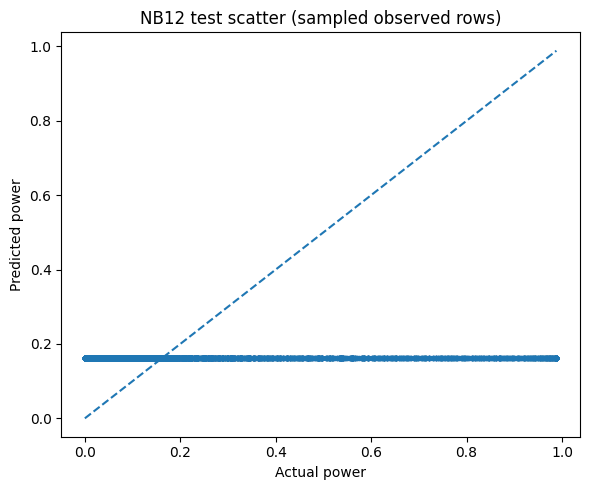

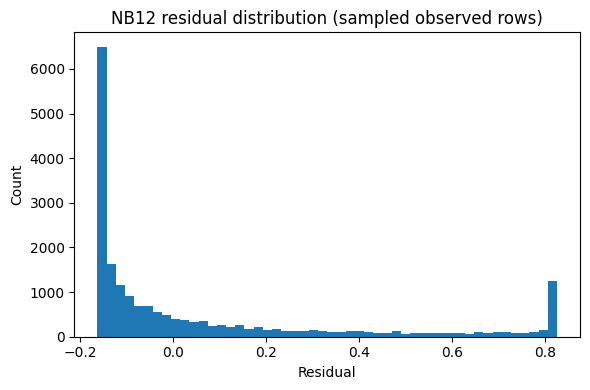

In [28]:
# ============================================================
# Test plots
# ============================================================

plot_sample_n = min(20000, len(test_predictions_df))
plot_df = test_predictions_df.sample(n=plot_sample_n, random_state=SEED).copy()

# Scatter: actual vs predicted
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(plot_df["y_true"], plot_df["y_pred"], s=8, alpha=0.4)
diag_min = float(min(plot_df["y_true"].min(), plot_df["y_pred"].min()))
diag_max = float(max(plot_df["y_true"].max(), plot_df["y_pred"].max()))
ax.plot([diag_min, diag_max], [diag_min, diag_max], linestyle="--")

ax.set_title("NB12 test scatter (sampled observed rows)")
ax.set_xlabel("Actual power")
ax.set_ylabel("Predicted power")

plt.tight_layout()
plt.show()

# Residual histogram
plot_df["residual"] = plot_df["y_true"] - plot_df["y_pred"]

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

ax.hist(plot_df["residual"], bins=50)
ax.set_title("NB12 residual distribution (sampled observed rows)")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Recovery cell for export dependencies
# ============================================================

if "history_df" not in globals():
    if "history" not in globals():
        raise RuntimeError("Λείπει και το `history`, άρα δεν μπορεί να ξαναχτιστεί το history_df.")
    history_df = pd.DataFrame(history)

required_objects = [
    "test_predictions_df",
    "nb12_test_metrics_df",
    "comparison_df",
    "best_state_dict",
    "best_epoch",
    "best_val_loss",
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Λείπουν required objects πριν από το export: {missing_objects}")

print("Recovery check passed.")
print("history_df rows:", len(history_df))
display(history_df.tail())

Recovery check passed.
history_df rows: 11


,epoch,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,val_r2
6,7,0.072815,0.196646,0.268224,0.061050,0.184877,0.239784,-0.342348
7,8,0.072823,0.196538,0.268097,0.061305,0.187091,0.240668,-0.362058
8,9,0.073162,0.196917,0.268371,0.060803,0.182420,0.238856,-0.321290
9,10,0.072898,0.196267,0.268198,0.061320,0.187216,0.240720,-0.363197
10,11,0.072821,0.197253,0.268185,0.060569,0.179608,0.237872,-0.298391


In [31]:
# ============================================================
# NB12-specific exports
# ============================================================

history_path = NB12_EXPORT_DIR / "nb12_training_history.csv"
test_predictions_path = NB12_EXPORT_DIR / "nb12_test_predictions_observed_only.csv"
metrics_path = NB12_EXPORT_DIR / "nb12_test_metrics.csv"
comparison_path = NB12_EXPORT_DIR / "nb12_benchmark_comparison.csv"
config_path = NB12_EXPORT_DIR / "nb12_run_config.json"
best_model_path = NB12_EXPORT_DIR / "nb12_best_model_state.pt"

history_df.to_csv(history_path, index=False)
test_predictions_df.to_csv(test_predictions_path, index=False)
nb12_test_metrics_df.to_csv(metrics_path, index=False)
comparison_df.to_csv(comparison_path, index=False)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "seed": SEED,
            "device": str(DEVICE),
            "training_config": TRAINING_CONFIG,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "input_feature_dim": train_dataset.n_input_features,
            "n_train_snapshots": len(train_dataset),
            "n_val_snapshots": len(val_dataset),
            "n_test_snapshots": len(test_dataset),
            "n_nodes": int(train_package["n_nodes"]),
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

torch.save(best_state_dict, best_model_path)

print("NB12 exports completed successfully.")
print("history_path         :", history_path)
print("test_predictions_path:", test_predictions_path)
print("metrics_path         :", metrics_path)
print("comparison_path      :", comparison_path)
print("config_path          :", config_path)
print("best_model_path      :", best_model_path)

NB12 exports completed successfully.
history_path         : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline\nb12_training_history.csv
test_predictions_path: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline\nb12_test_predictions_observed_only.csv
metrics_path         : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline\nb12_test_metrics.csv
comparison_path      : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline\nb12_benchmark_comparison.csv
config_path          : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline\nb12_run_config.json
best_model_path      : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\graph_baselines\nb12_first_graph_baseline\nb12_best_model_state.pt


In [32]:
# ============================================================
# Final NB12 sanity check
# ============================================================

required_export_paths = {
    "history_path": history_path,
    "test_predictions_path": test_predictions_path,
    "metrics_path": metrics_path,
    "comparison_path": comparison_path,
    "config_path": config_path,
    "best_model_path": best_model_path,
}

missing_exports = [name for name, path in required_export_paths.items() if not Path(path).exists()]
if missing_exports:
    raise FileNotFoundError(f"Λείπουν NB12 exports: {missing_exports}")

if test_predictions_df.empty:
    raise RuntimeError("Το test_predictions_df είναι κενό.")

if comparison_df.empty:
    raise RuntimeError("Το comparison_df είναι κενό.")

if nb12_test_metrics_df.empty:
    raise RuntimeError("Το nb12_test_metrics_df είναι κενό.")

print("NB12 SANITY CHECK PASSED")
print("Best epoch      :", best_epoch)
print("Best val loss   :", best_val_loss)
print("Test MAE        :", float(nb12_test_metrics_df.loc[0, "MAE"]))
print("Test RMSE       :", float(nb12_test_metrics_df.loc[0, "RMSE"]))
print("Test R2         :", float(nb12_test_metrics_df.loc[0, "R2"]))
print("Observed rows   :", len(test_predictions_df))
print("Missing exports :", len(missing_exports))

NB12 SANITY CHECK PASSED
Best epoch      : 5
Best val loss   : 0.06048211165600353
Test MAE        : 0.2177424039668681
Test RMSE       : 0.30926228878733425
Test R2         : -0.03694281122153131
Observed rows   : 1086336
Missing exports : 0


## NB12 result summary

Το `NB12` ολοκληρώθηκε επιτυχώς ως το πρώτο actual graph-based forecasting baseline
πάνω στα canonical packaged artifacts του `NB11`.

### Τι επιβεβαιώθηκε τεχνικά
- επιτυχές graph-model training run
- validation-driven model selection
- successful best-checkpoint restore
- successful test-set evaluation
- benchmark-safe comparison χωρίς mutation του `baseline_metrics.csv`
- successful NB12-specific exports

### Μεθοδολογική ερμηνεία
Το notebook αποτελεί πλέον ένα **reproducible και benchmark-safe graph baseline entry point**.

Ωστόσο, το current αποτέλεσμα πρέπει να ερμηνευθεί προσεκτικά:
- αποτελεί **πρώτο baseline pass**
- δεν αρκεί μόνο του για claim ανωτερότητας έναντι των tabular baselines
- δεν αποτελεί ακόμη graph ablation study
- δεν ανοίγει sequence-model ή PHM claim scope

### Safe takeaway
Το `NB12` απέδειξε ότι το repository διαθέτει πλέον
λειτουργικό πρώτο graph-based forecasting baseline,
αλλά η περαιτέρω βελτίωση του graph modeling παραμένει επόμενο βήμα και όχι τελικό συμπέρασμα.